# Consumption profiles with `NewDatabase`

This notebook illustrates the three methods to declare consumption profiles with `shrecc`. 

In [1]:
from pathlib import Path

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from shrecc import NewDatabase
from shrecc.analysis import (
    compare_electricity_generation_mixes,
    compare_electricity_lcia,
)

%load_ext jupyter_black

In [4]:
# Geographical scope and common 52-week annual period
years = [2021, 2025, 2035, 2040]
countries = ["ES", "FR", "DE", "IT", "PT", "BE", "NL", "LU", "AT", "CH"]
time_range = ["2040-01-01 00:00:00", "2040-12-30 23:00:00"]
country_to_compare = "FR"

# Brightway configuration
project_name = "SHRECCei311"
my_db_name = "shrecc_annual_profiles"
bg_db_name = {
    2021: "ecoinvent-3.11-cutoff",
    2025: "ecoinvent-3.11-cutoff",
    2035: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10",
    2040: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10",
}
write_database = True

climate_method = (
    "ecoinvent-3.11",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)

## Create the flat consumption profile

In this paradigm, all hours "are created equal", a low-demand hour has the same weight as a high-demand hour.

In [5]:
flat_consumption = NewDatabase(
    years=years,
    scenario="DE",
    climate_year=2009,
    countries=countries,
    time_range=time_range,
    project_name=project_name,
    my_db_name=f"{my_db_name}_flat",
    bg_db_name=bg_db_name,
    include_consumption_mix_volume=False,
    retain_hourly_results=False,
    consumption_profile="flat",
)

In [6]:
flat_consumption.create()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\3115011916.py:1: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 25.0%, BE 8.4%, IT 6.9%, LU 5.3%, DE 2.9%. Largest source-technology gaps: NL/Others 21.6%, IT/Others 6.0%, BE/Others 5.3%, NL/Waste non-renewable 2.7%, BE/Waste non-renewable 1.9%. See mapping_report(2021) for the full report.
  flat_consumption.create()
C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\3115011916.py:1: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 35.4%, BE 13.5%, LU 6.8%, IT 6.5%, CH 4.6%. Largest source-technology gaps: NL/Others 32.4%, BE/Others 7.4%, IT/Others 5.8%, CH/Others 4.2%, BE/Waste non-renewable 2.3%. See mapping_report(2025) for the full report.
  flat_consumption.create()
D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureWarning: 

NewDatabase(years=[2021, 2025, 2035, 2040], sources={2021:energy_charts, 2025:energy_charts, 2035:tyndp, 2040:tyndp})

## Create the national demand profile

This creates inventories that are representative of the _volumes_ of electricity consumed nationally. This is implicitly what every annual-average dataset is offering, including ecoinvent and premise.

In [7]:
national_consumption = NewDatabase(
    years=years,
    scenario="DE",
    climate_year=2009,
    countries=countries,
    time_range=time_range,
    project_name=project_name,
    my_db_name=f"{my_db_name}_national_demand",
    bg_db_name=bg_db_name,
    include_consumption_mix_volume=False,
    retain_hourly_results=False,
    consumption_profile="national_demand",
)

In [8]:
national_consumption.create()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\1195316831.py:1: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 24.6%, BE 8.4%, IT 6.8%, LU 5.2%, DE 2.8%. Largest source-technology gaps: NL/Others 21.2%, IT/Others 5.9%, BE/Others 5.3%, NL/Waste non-renewable 2.6%, BE/Waste non-renewable 1.9%. See mapping_report(2021) for the full report.
  national_consumption.create()
C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\1195316831.py:1: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 35.0%, BE 13.5%, LU 6.6%, IT 6.4%, CH 4.6%. Largest source-technology gaps: NL/Others 32.1%, BE/Others 7.4%, IT/Others 5.6%, CH/Others 4.1%, BE/Waste non-renewable 2.2%. See mapping_report(2025) for the full report.
  national_consumption.create()
D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureW

NewDatabase(years=[2021, 2025, 2035, 2040], sources={2021:energy_charts, 2025:energy_charts, 2035:tyndp, 2040:tyndp})

## Custom consumption profile

In some LCA studies, you may have access to hourly consumption profiles, which are usually quite different from a flat or national-demand shape (if you study storage technologies, you typically look for load-shifting behaviours).

We can use external data sources to exemplify this, e.g. the ELMAS datasets, developed by MinesParisTech, publicly available [here](https://figshare.com/articles/dataset/ELMAS_dataset/23889780).

In [9]:
ELMAS_CLUSTER_LABELS = {
    "1": "Manufacturing processes",
    "2": "Trades (non-food)",
    "3": "Trades (food)",
    "4": "Education",
    "5": "Office",
    "6": "Crop farming and transportation",
    "7": "Livestock farming",
    "8": "Water supply and telecommunications",
    "9": "Restaurants",
    "10": "Food industry",
    "11": "Wine industry",
    "12": "Energy supply and rental activities",
    "13": "Hotels",
    "14": "Bakery",
    "15": "Property management companies",
    "16": "Hospital activities",
    "17": "Recreational and social activities",
    "18": "Construction",
}

In [10]:
profile_path = Path("../data/profiles/ELMAS_dataset") / "Time_series_18_clusters.csv"

elmas_profiles = pd.read_csv(
    profile_path,
    sep=";",
    decimal=",",
    parse_dates=["Time"],
).set_index("Time")

elmas_profiles = elmas_profiles.rename(columns=ELMAS_CLUSTER_LABELS)

Text(0, 0.5, 'Average power (MW)')

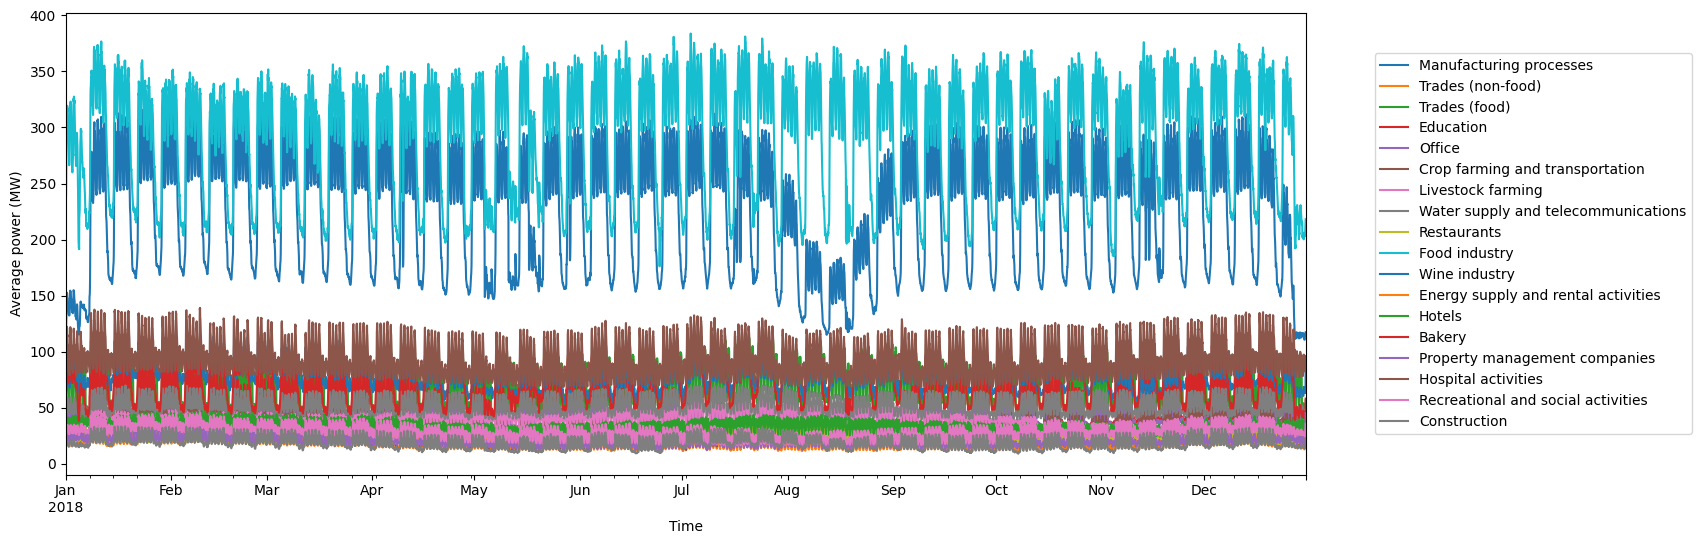

In [11]:
ax = (elmas_profiles / 1_000).plot(figsize=(16, 6))

ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_ylabel("Average power (MW)")

Hourly solver results are not retained in this comparison. Keeping only the
profile-weighted activity mixes and database tables prevents several
multi-gigabyte annual arrays from accumulating across the three assumptions.


In [12]:
# ELMAS contains 52 weeks from 2018. Rebase its calendar to the model year.
target_year = pd.Timestamp(time_range[0]).year
livestock_profile = elmas_profiles["Livestock farming"].copy()
livestock_profile.index += pd.DateOffset(
    years=target_year - livestock_profile.index[0].year
)

<Axes: title={'center': 'Annual ELMAS livestock consumption profile'}, xlabel='Time', ylabel='Hourly consumption (kWh)'>

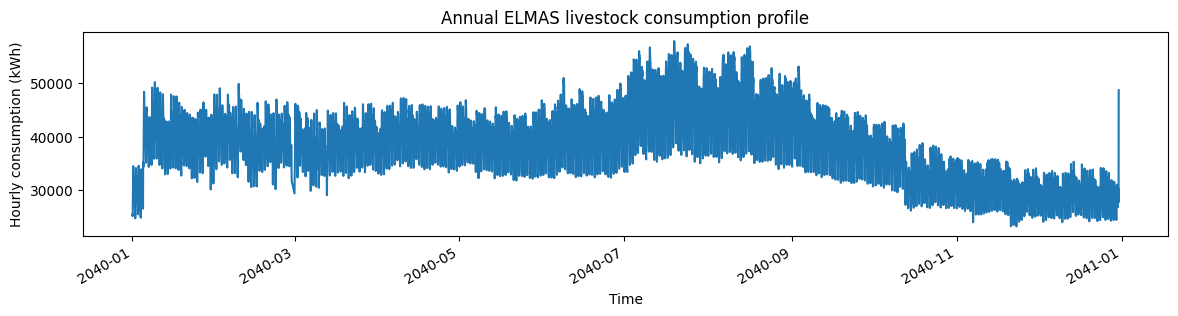

In [13]:
# The custom Series defines the same full 52-week annual scope.
livestock_profile.plot(
    figsize=(14, 3),
    ylabel="Hourly consumption (kWh)",
    title="Annual ELMAS livestock consumption profile",
)

In [14]:
livestock_profile.describe()

count     8736.000000
mean     38978.424272
std       6784.781066
min      23166.054467
25%      33931.813592
50%      39453.449099
75%      43422.939787
max      57949.427874
Name: Livestock farming, dtype: float64

In [15]:
custom_consumption = NewDatabase(
    years=years,
    scenario="DE",
    climate_year=2009,
    countries=countries,
    project_name=project_name,
    my_db_name=f"{my_db_name}_elmas_livestock",
    bg_db_name=bg_db_name,
    include_consumption_mix_volume=False,
    retain_hourly_results=False,
    consumption_profile=livestock_profile,
)

In [16]:
custom_consumption.create()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\1656286824.py:1: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 25.9%, BE 8.3%, IT 6.8%, LU 5.3%, DE 2.8%. Largest source-technology gaps: NL/Others 22.4%, IT/Others 5.9%, BE/Others 5.3%, NL/Waste non-renewable 2.7%, BE/Waste non-renewable 1.9%. See mapping_report(2021) for the full report.
  custom_consumption.create()
C:\Users\Gibon\AppData\Local\Temp\ipykernel_26784\1656286824.py:1: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 37.0%, BE 13.5%, LU 6.7%, IT 6.4%, CH 4.6%. Largest source-technology gaps: NL/Others 34.0%, BE/Others 7.3%, IT/Others 5.7%, CH/Others 4.2%, BE/Waste non-renewable 2.3%. See mapping_report(2025) for the full report.
  custom_consumption.create()
D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureWarni

NewDatabase(years=[2021, 2025, 2035, 2040], sources={2021:energy_charts, 2025:energy_charts, 2035:tyndp, 2040:tyndp})

## Compare electricity mixes

The three SHRECC inventories and the corresponding background low-voltage
market are resolved to their generating activities. This follows the same
delivered-electricity comparison used in the annual validation notebook.


In [ ]:
profile_models = {
    "Flat": flat_consumption,
    "National demand": national_consumption,
    "ELMAS livestock": custom_consumption,
}
model_order = [*profile_models, "Background"]

bd.projects.set_current(project_name)

missing_backgrounds = {
    name
    for name in flat_consumption.background_databases.values()
    if name not in bd.databases
}
if missing_backgrounds:
    raise ValueError(f"Missing background databases: {missing_backgrounds}")
if climate_method not in bd.methods:
    raise ValueError(f"Brightway method is not installed: {climate_method}")
if not write_database:
    raise RuntimeError(
        "Set write_database=True to compare resolved inventories and calculate LCIA."
    )

for label, model in profile_models.items():
    print(f"Writing {label} inventories")
    model.write()

Writing Flat inventories


100%|██████████| 10/10 [00:00<00:00, 111.15it/s]


21:52:17+0200 [info     ] Vacuuming database            


In [ ]:
comparison_foregrounds = {
    label: model.database_names for label, model in profile_models.items()
}
comparison_backgrounds = flat_consumption.background_databases

In [ ]:
mix_comparison, mix_gaps, mix_resolution_diagnostics = (
    compare_electricity_generation_mixes(
        comparison_foregrounds,
        comparison_backgrounds,
        countries=countries,
        years=years,
    )
)

display(mix_gaps if not mix_gaps.empty else "No electricity-mix comparison gaps")
display(mix_resolution_diagnostics.head())
display(mix_comparison.head())

'No electricity-mix comparison gaps'

,year,country,model,root activity,iterations,terminal generation volume,remaining wrapper volume,nonstandard terminal volume
0,2025,ES,Flat,"Electricity mix in ES, 2025",27,1.000216,9.799421e-11,0.000000
1,2025,ES,National demand,"Electricity mix in ES, 2025",27,1.000219,9.924453e-11,0.000000
2,2025,ES,ELMAS livestock,"Electricity mix in ES, 2025",27,1.000213,9.677591e-11,0.000000
3,2025,ES,Background,"market for electricity, low voltage",29,1.140386,8.454322e-11,0.000463
4,2025,FR,Flat,"Electricity mix in FR, 2025",28,1.000393,9.985721e-11,0.000000


,year,country,model,technology,share
0,2025,ES,Flat,"electricity production, natural gas, combined ...",0.191936
1,2025,ES,Flat,"electricity production, nuclear, pressure wate...",0.177601
2,2025,ES,Flat,"electricity production, wind, 1-3MW turbine, o...",0.143838
3,2025,ES,Flat,"electricity production, hydro, reservoir, non-...",0.085030
4,2025,ES,Flat,"electricity production, wind, <1MW turbine, on...",0.076484


(<Figure size 1300x930 with 3 Axes>,
 array([<Axes: ylabel='2025'>, <Axes: ylabel='2035'>,
        <Axes: xlabel='Electricity share', ylabel='2040'>], dtype=object))

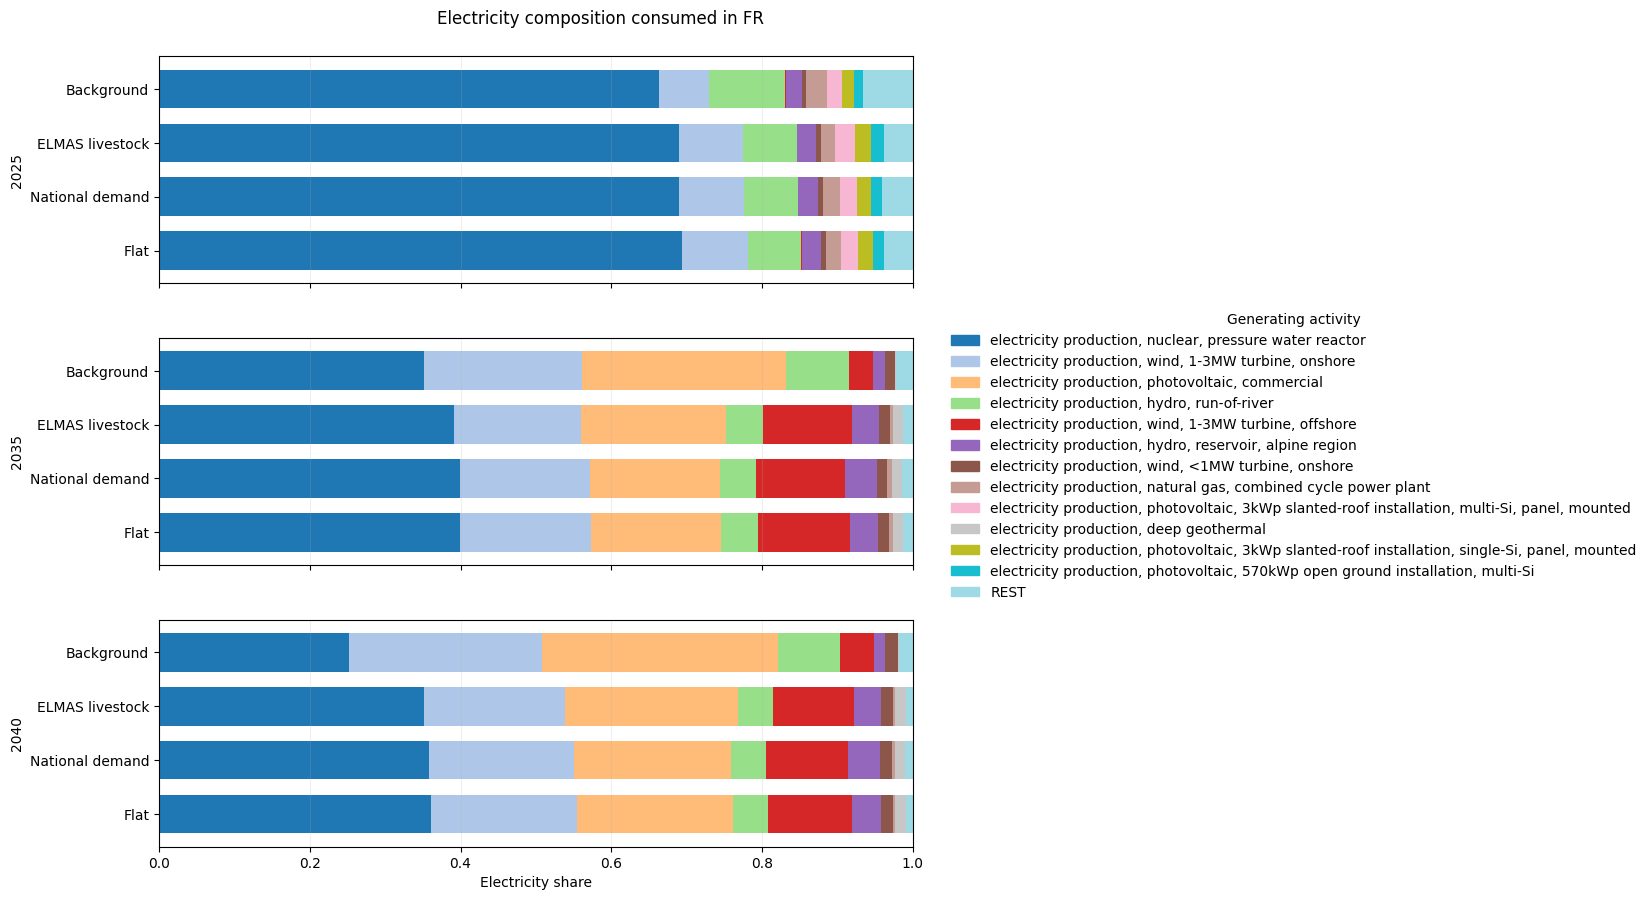

In [ ]:
def plot_profile_mix_comparison(country, top_n=12):
    country_data = mix_comparison.loc[mix_comparison["country"] == country].copy()
    if country_data.empty:
        raise ValueError(f"No electricity-mix comparison data for {country}")

    leading_technologies = (
        country_data.groupby("technology")["share"].sum().nlargest(top_n).index
    )
    country_data["technology_plot"] = country_data["technology"].where(
        country_data["technology"].isin(leading_technologies),
        "REST",
    )
    technologies = list(leading_technologies) + ["REST"]
    colors = dict(zip(technologies, plt.cm.tab20(np.linspace(0, 1, len(technologies)))))

    fig, axes = plt.subplots(
        len(years),
        1,
        figsize=(13, 3.1 * len(years)),
        sharex=True,
        squeeze=False,
    )
    axes = axes[:, 0]

    for year, ax in zip(years, axes):
        plotted = (
            country_data.loc[country_data["year"] == year]
            .pivot_table(
                index="model",
                columns="technology_plot",
                values="share",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(
                index=model_order,
                columns=technologies,
                fill_value=0,
            )
        )
        plotted.plot.barh(
            stacked=True,
            ax=ax,
            color=[colors[column] for column in plotted.columns],
            legend=False,
            width=0.72,
        )
        ax.set(ylabel=str(year), xlim=(0, 1))
        ax.grid(axis="x", alpha=0.2)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[label], label=label)
        for label in technologies
    ]
    fig.legend(
        handles=handles,
        title="Generating activity",
        loc="center left",
        bbox_to_anchor=(0.76, 0.5),
        frameon=False,
    )
    axes[-1].set_xlabel("Electricity share")
    fig.suptitle(f"Electricity composition consumed in {country}")
    fig.subplots_adjust(
        left=0.16,
        right=0.74,
        top=0.93,
        bottom=0.08,
        hspace=0.24,
    )
    return fig, axes


plot_profile_mix_comparison(country_to_compare)

## Compare climate-change impacts

Each score represents 1 kWh of delivered low-voltage electricity. The three
consumption-profile assumptions are compared with the same background market
for each country and model year.


In [ ]:
lcia_results, lcia_gaps = compare_electricity_lcia(
    comparison_foregrounds,
    comparison_backgrounds,
    countries=countries,
    years=years,
    method=climate_method,
    verbose=True,
)
display(lcia_gaps if not lcia_gaps.empty else "No LCIA activity gaps")

lcia_comparison = lcia_results.pivot_table(
    index=["year", "country"],
    columns="model",
    values="score",
).reindex(columns=model_order)

for model in profile_models:
    lcia_comparison[f"{model} difference (%)"] = (
        100
        * (lcia_comparison[model] - lcia_comparison["Background"])
        / lcia_comparison["Background"]
    )

display(lcia_comparison)

Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2025
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2035
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2040


'No LCIA activity gaps'

model             Flat  National demand  ELMAS livestock  Background  \
year country                                                           
2025 AT       0.193973         0.204050         0.186476    0.248834   
     BE       0.184178         0.187463         0.182849    0.179910   
     CH       0.058658         0.060066         0.058045    0.030125   
     DE       0.380020         0.384087         0.376362    0.437529   
     ES       0.166074         0.167051         0.164212    0.203927   
     FR       0.047275         0.049900         0.047517    0.087979   
     IT       0.308668         0.312706         0.303759    0.351726   
     LU       0.274832         0.280812         0.272087    0.337051   
     NL       0.417854         0.421168         0.420976    0.397066   
     PT       0.161770         0.161214         0.160940    0.233042   
2035 AT       0.019272         0.020267         0.018526    0.037328   
     BE       0.035668         0.039004         0.034123    0.037328   
     CH       0.017994         0.018805         0.017855    0.015370   
     DE       0.029489         0.031538         0.028334    0.056260   
     ES       0.028970         0.029884         0.028183    0.054733   
     FR       0.015663         0.016329         0.015659    0.020311   
     IT       0.047684         0.049197         0.044980    0.044262   
     LU       0.028094         0.029245         0.027562    0.037328   
     NL       0.037442         0.040035         0.035973    0.037328   
     PT       0.032879         0.032456         0.032167    0.054733   
2040 AT       0.013663         0.013909         0.013479    0.018415   
     BE       0.025428         0.027357         0.024605    0.018415   
     CH       0.012480         0.012904         0.012083    0.013234   
     DE       0.017512         0.017852         0.017323    0.021122   
     ES       0.017722         0.017678         0.017483    0.017135   
     FR       0.011141         0.011311         0.011211    0.013887   
     IT       0.025399         0.027042         0.024475    0.016837   
     LU       0.019956         0.020464         0.019688    0.018415   
     NL       0.022042         0.023583         0.021262    0.018415   
     PT       0.019634         0.019490         0.019156    0.017135   

model         Flat difference (%)  National demand difference (%)  \
year country                                                        
2025 AT                -22.047172                      -17.997601   
     BE                  2.372454                        4.198115   
     CH                 94.715594                       99.390480   
     DE                -13.144047                      -12.214324   
     ES                -18.561952                      -18.083190   
     FR                -46.265757                      -43.281372   
     IT                -12.241949                      -11.093807   
     LU                -18.459965                      -16.685591   
     NL                  5.235616                        6.070194   
     PT                -30.583254                      -30.821699   
2035 AT                -48.370915                      -45.705102   
     BE                 -4.446554                        4.490595   
     CH                 17.070228                       22.346816   
     DE                -47.584853                      -43.941237   
     ES                -47.071011                      -45.400286   
     FR                -22.884249                      -19.606801   
     IT                  7.730155                       11.148182   
     LU                -24.738019                      -21.653096   
     NL                  0.305620                        7.252662   
     PT                -39.929518                      -40.700793   
2040 AT                -25.803861                      -24.469315   
     BE                 38.083247                       48.555204   
     CH                 -5.696282      

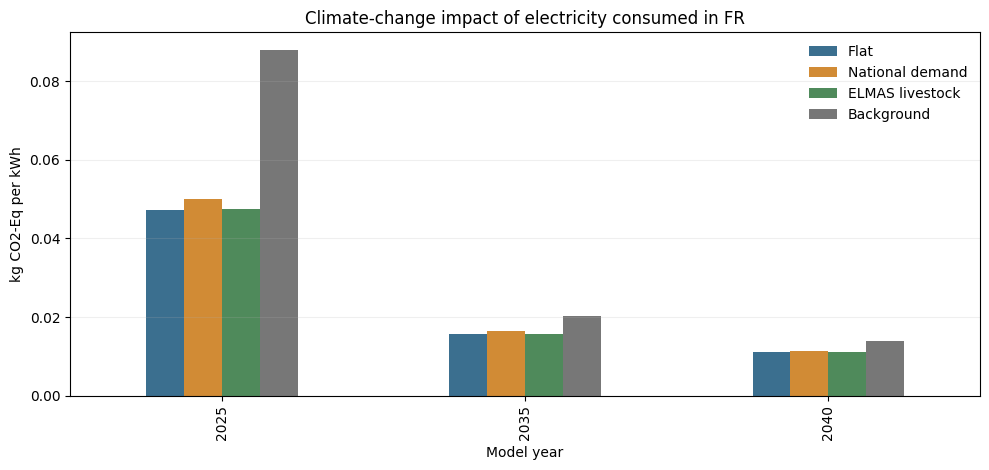

In [ ]:
method_unit = bd.Method(climate_method).metadata.get("unit", "kg CO2-eq")

country_lcia = (
    lcia_results.loc[lcia_results["country"] == country_to_compare]
    .pivot(index="year", columns="model", values="score")
    .reindex(index=years, columns=model_order)
)

ax = country_lcia.plot.bar(
    figsize=(10, 4.8),
    color={
        "Flat": "#3B6F8F",
        "National demand": "#D18B35",
        "ELMAS livestock": "#4F8A5B",
        "Background": "#777777",
    },
)
ax.set(
    title=("Climate-change impact of electricity consumed " f"in {country_to_compare}"),
    xlabel="Model year",
    ylabel=f"{method_unit} per kWh",
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()